In [1]:
cd /content/drive/MyDrive/projects/Nadir

/content/drive/MyDrive/projects/Nadir


In [2]:
ls

0_simulation.ipynb  Fig2.gdraw


In [9]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa
from sklearn.linear_model import Ridge
from tqdm import tqdm
import warnings
from scipy.linalg import LinAlgWarning
warnings.filterwarnings('ignore', category=LinAlgWarning)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0); np.random.seed(0)
print('device:', device)

device: cuda


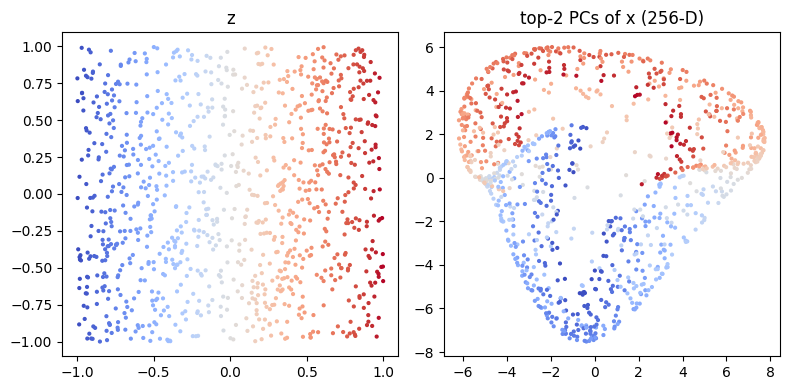

In [10]:
N_LATENT = 2
N_AMBIENT = 256          # high-D ambient space; analog of pixel space in SVG-World
N_TRAIN, N_TEST = 8000, 2000

def sample_z(n, seed):
    g_ = torch.Generator(device=device).manual_seed(seed)
    return torch.empty(n, N_LATENT, device=device).uniform_(-1.0, 1.0, generator=g_)

# Deterministic Fourier-feature lift z ∈ R^2 → x ∈ R^{N_AMBIENT}.
# x_j = cos(w_j · z + b_j); injective (whp), nonlinear, smooth, no stochastic noise.
gen = torch.Generator(device=device).manual_seed(7)
W_lift = torch.randn(N_LATENT, N_AMBIENT, generator=gen, device=device) * 3.0
b_lift = torch.rand(N_AMBIENT, generator=gen, device=device) * 2 * np.pi

def g(z):
    return torch.cos(z @ W_lift + b_lift)

z_train = sample_z(N_TRAIN, seed=1)
z_test  = sample_z(N_TEST,  seed=2)
x_train = g(z_train).detach()
x_test  = g(z_test).detach()

NORM_THRESH = 0.8
ccgp_train_in_mask = (z_train.norm(dim=1) < NORM_THRESH).cpu().numpy()
ccgp_test_in_mask  = (z_test.norm(dim=1)  < NORM_THRESH).cpu().numpy()
ccgp_test_out_mask = (z_test.norm(dim=1) >= NORM_THRESH).cpu().numpy()

# Sanity plot: x is now high-D, show its top-2 PCs colored by z₀
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(z_train[:1000,0].cpu(), z_train[:1000,1].cpu(),
              c=z_train[:1000,0].cpu(), s=4, cmap='coolwarm'); ax[0].set_title('z')
xc = (x_train - x_train.mean(0)).cpu().numpy()
_, _, Vt = np.linalg.svd(xc[:1000], full_matrices=False)
xp = xc[:1000] @ Vt[:2].T
ax[1].scatter(xp[:,0], xp[:,1], s=4,
              c=z_train[:1000,0].cpu(), cmap='coolwarm')
ax[1].set_title(f'top-2 PCs of x ({N_AMBIENT}-D)')
plt.tight_layout(); plt.show()

In [11]:
class OneLayerMLP(nn.Module):
    """f(x) = ReLU(W x + b). Output is post-ReLU, dim = n_hidden."""
    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
    def forward(self, x):
        return F.relu(self.fc1(x))

class TwoLayerMLP(nn.Module):
    """f(x) = W2 ReLU(W1 x + b1) + b2. Output is signed, dim = n_hidden."""
    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

In [12]:
def forward_r2(f_tr, z_tr, f_te, z_te, alpha=1e-3):
    reg = Ridge(alpha=alpha).fit(f_tr, z_tr)
    z_hat = reg.predict(f_te)
    r2 = np.array([r2_score(z_te[:, j], z_hat[:, j]) for j in range(z_tr.shape[1])])
    return r2, reg.coef_  # (k,), (k, d)

def reverse_r2(f_tr, z_tr, f_te, z_te, alpha=1e-3):
    """Total f-variance explained by linear function of z (one scalar)."""
    reg = Ridge(alpha=alpha).fit(z_tr, f_tr)
    f_hat = reg.predict(z_te)
    sse = ((f_te - f_hat)**2).sum()
    sst = ((f_te - f_te.mean(axis=0, keepdims=True))**2).sum()
    return float(1 - sse / sst)

def subspace_alignment(W_fwd, f_tr, k=None):
    """
    Mean cos² of principal angles between col(W_fwd^T) and top-k PCs of f.
    1 = perfect alignment, 0 = orthogonal.
    """
    if k is None: k = W_fwd.shape[0]
    U_dec, _ = np.linalg.qr(W_fwd.T)
    U_dec = U_dec[:, :k]
    fc = f_tr - f_tr.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(fc, full_matrices=False)
    U_pca = Vt[:k].T
    sigmas = np.linalg.svd(U_dec.T @ U_pca, compute_uv=False)
    return float(np.mean(sigmas**2))

def reverse_r2_at_k(f_tr, z_tr, f_te, z_te, k, alpha=1e-3):
    """Reverse R² when f is first projected onto its top-k PCs."""
    mu = f_tr.mean(0, keepdims=True)
    fc_tr = f_tr - mu
    _, _, Vt = np.linalg.svd(fc_tr, full_matrices=False)
    P = Vt[:k].T  # (d, k)
    f_tr_k = fc_tr @ P
    f_te_k = (f_te - mu) @ P
    return reverse_r2(f_tr_k, z_tr, f_te_k, z_te, alpha=alpha)

def spectral_concentration(f_tr, z_tr, f_te, z_te, k_latent, alpha=1e-3):
    """Fraction of *total f-variance* that is both z-explainable and in top-k_latent PCs.
    Bounded in [0, 1]. = 1 iff all z-aligned variance is concentrated in top-k_latent PCs.
    """
    mu = f_tr.mean(0, keepdims=True)
    fc_tr, fc_te = f_tr - mu, f_te - mu
    _, _, Vt = np.linalg.svd(fc_tr, full_matrices=False)
    P = Vt[:k_latent].T
    f_tr_k, f_te_k = fc_tr @ P, fc_te @ P
    # numerator: variance of top-k projection that is linear in z
    reg = Ridge(alpha=alpha).fit(z_tr, f_tr_k)
    f_hat = reg.predict(z_te)
    var_explained_in_topk = ((f_hat - f_hat.mean(0))**2).sum()
    # denominator: total f-variance
    total_var = (fc_te**2).sum()
    return float(var_explained_in_topk / total_var)

In [13]:
def train_supervised(
    model, x_tr, z_tr,
    n_steps=2000,           # was 3000
    lr=2e-3,
    batch_size=256,
    weight_decay=1.0,       # was 1e-2
    ):
    """Train f + linear readout U so that U f(x) ≈ z."""
    with torch.no_grad():
        d = model(x_tr[:1]).shape[-1]
    readout = nn.Linear(d, N_LATENT).to(device)
    opt = torch.optim.AdamW(
        list(model.parameters()) + list(readout.parameters()),
        lr=lr, weight_decay=weight_decay,
    )

    n = x_tr.shape[0]
    for step in range(n_steps):
        idx = torch.randint(0, n, (batch_size,), device=device)
        loss = F.mse_loss(readout(model(x_tr[idx])), z_tr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    return model

In [15]:
WIDTHS = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
WDS    = [0.0, 1.0]
N_SEEDS = 5

z_tr_np, z_te_np = z_train.cpu().numpy(), z_test.cpu().numpy()
def features(model, x):
    model.eval()
    with torch.no_grad(): return model(x).cpu().numpy()

def evaluate(f_tr, f_te):
    r2_fwd, _ = forward_r2(f_tr, z_tr_np, f_te, z_te_np)
    r2_rev = reverse_r2(f_tr, z_tr_np, f_te, z_te_np)
    sc     = spectral_concentration(f_tr, z_tr_np, f_te, z_te_np, k_latent=N_LATENT)
    r2_out, _ = forward_r2(f_tr[ccgp_train_in_mask], z_tr_np[ccgp_train_in_mask],
                           f_te[ccgp_test_out_mask], z_te_np[ccgp_test_out_mask])
    return dict(fwd=r2_fwd.mean(), rev=r2_rev, sconc=sc, ccgp_out=r2_out.mean())

results = []
for seed in range(N_SEEDS):
    print('generating random')
    for width in tqdm(WIDTHS):
        torch.manual_seed(seed)
        model = TwoLayerMLP(N_AMBIENT, width).to(device)
        m = evaluate(features(model, x_train), features(model, x_test))
        results.append(dict(width=width, cond='random', wd=None, seed=seed, **m))
    for wd in WDS:
        print('seed', seed, 'wd', wd)
        for width in tqdm(WIDTHS):
            torch.manual_seed(seed)
            model = TwoLayerMLP(N_AMBIENT, width).to(device)
            model = train_supervised(model, x_train, z_train, weight_decay=wd)
            m = evaluate(features(model, x_train), features(model, x_test))
            results.append(dict(width=width, cond='trained', wd=wd, seed=seed, **m))
    print(f'seed {seed} done')

df_wd = pd.DataFrame(results)
df_wd.to_csv('df_simulation_sweep.csv', index=False)
df_wd

generating random


100%|██████████| 9/9 [00:09<00:00,  1.02s/it]


seed 0 wd 0.0


100%|██████████| 9/9 [00:34<00:00,  3.79s/it]


seed 0 wd 1.0


...

100%|██████████| 9/9 [00:40<00:00,  4.47s/it]


seed 4 wd 1.0


100%|██████████| 9/9 [00:40<00:00,  4.53s/it]

seed 4 done


,width,cond,wd,seed,fwd,rev,sconc,ccgp_out
0,4,random,NaN,0,0.216152,0.209684,0.211356,-0.244062
1,8,random,NaN,0,0.476823,0.179103,0.147744,0.145102
2,16,random,NaN,0,0.718798,0.215145,0.169176,0.156366
3,32,random,NaN,0,0.909673,0.165488,0.094167,0.436732
4,64,random,NaN,0,0.983018,0.166174,0.085763,0.745884
...,...,...,...,...,...,...,...,...
130,64,trained,1.0,4,0.999976,0.996212,0.996382,0.999827
131,128,trained,1.0,4,0.999979,0.998503,0.998368,0.999574
132,256,trained,1.0,4,0.999974,0.998470,0.997680,0.999720
133,512,trained,1.0,4,0.999987,0.998068,0.997661,0.999935


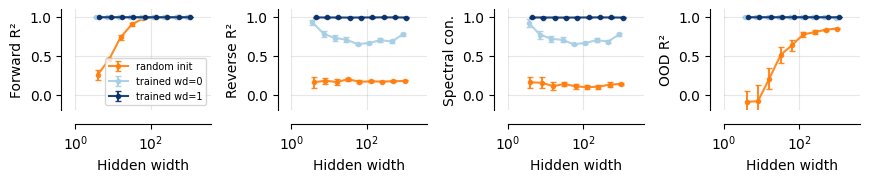

In [19]:
metrics = [('fwd', 'Forward R²'), ('rev', 'Reverse R²'),
           ('sconc', 'Spectral con.'), ('ccgp_out', 'OOD R²')]

plot_size = 0.55
fig, axes = plt.subplots(1, 4, figsize=plot_size * np.array((16, 3.5)), sharex=True)
cmap = plt.cm.Blues
limits = (-0.2, 1.1)

def plot_series(ax, df, m, label, color, x_jitter=1.0):
    g = df.groupby('width')[m].agg(['mean', 'std']).reset_index()
    ax.errorbar(g['width'] * x_jitter, g['mean'], yerr=g['std'],
                fmt='.-', color=color, label=label, capsize=2, alpha=0.9)

for c, (m, label) in enumerate(metrics):
    ax = axes[c]
    plot_series(ax, df_wd[df_wd.cond == 'random'], m, 'random init', 'C1')
    for i, wd in enumerate(WDS):
        sub = df_wd[(df_wd.cond == 'trained') & (df_wd.wd == wd)]
        col = cmap(0.35 + 0.65 * i / max(1, len(WDS)-1))
        wd_label = f'trained wd={wd:.0f}' if wd > 0 else 'trained wd=0'
        x_jitter = 1.0 + 0.2 * (i - (len(WDS) - 1) / 2)
        plot_series(ax, sub, m, wd_label, col, x_jitter)
    ax.set_xscale('log')
    ax.set_ylabel(label)
    ax.set_xlabel('Hidden width')
    if c == 0:
        ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim(*limits)
    sns.despine(offset=10)
    ax.set_xlim(1, 2**12)

plt.tight_layout()
plt.savefig('fig_simulation_performance.png', dpi=500)
plt.show()

In [20]:
WIDTH, WD = 1024, 1.0

torch.manual_seed(42)
model_t = TwoLayerMLP(N_AMBIENT, WIDTH).to(device)
model_t = train_supervised(model_t, x_train, z_train, weight_decay=WD)
torch.manual_seed(42)
model_r = TwoLayerMLP(N_AMBIENT, WIDTH).to(device)

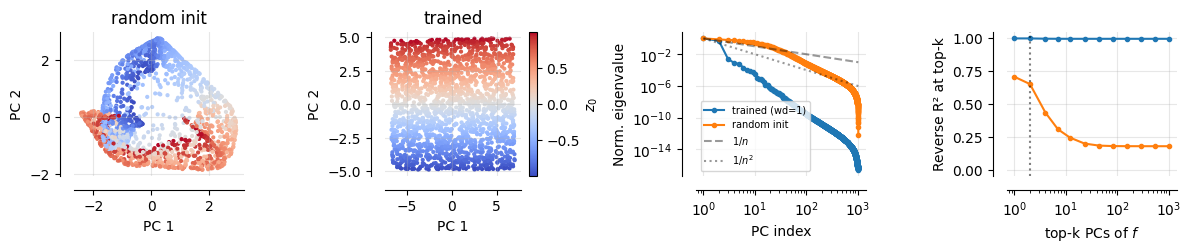

In [21]:
def prep(model):
    f_tr = features(model, x_train); f_te = features(model, x_test)
    mu = f_tr.mean(0, keepdims=True)
    fc_tr, fc_te = f_tr - mu, f_te - mu
    _, s, Vt = np.linalg.svd(fc_tr, full_matrices=False)
    return dict(fc_tr=fc_tr, fc_te=fc_te, s=s, Vt=Vt)

P_t, P_r = prep(model_t), prep(model_r)

def rev_curve(P, z_tr, z_te, ks, alpha=1e-3):
    Z_tr = np.concatenate([z_tr, np.ones((len(z_tr), 1))], axis=1)
    Z_te = np.concatenate([z_te, np.ones((len(z_te), 1))], axis=1)
    ZtZ_inv = np.linalg.inv(Z_tr.T @ Z_tr + alpha * np.eye(Z_tr.shape[1]))
    out = []
    for k in ks:
        Q = P['Vt'][:k].T
        F_te_k = P['fc_te'] @ Q
        W = ZtZ_inv @ Z_tr.T @ (P['fc_tr'] @ Q)
        F_hat = Z_te @ W
        sse = ((F_te_k - F_hat)**2).sum()
        sst = ((F_te_k - F_te_k.mean(0, keepdims=True))**2).sum()
        out.append(float(1 - sse / sst))
    return out

plot_size = 0.75
fig, axes = plt.subplots(1, 4, figsize=plot_size * np.array((16, 3.5)))

# (0, 1) top-2 PC scatter
for ax, P, title in [(axes[0], P_r, 'random init'), (axes[1], P_t, 'trained')]:
    proj = P['fc_te'] @ P['Vt'][:2].T
    sc = ax.scatter(proj[:,0], proj[:,1], c=z_test[:,0].cpu(), s=4, cmap='coolwarm')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_title(title)
    sns.despine(offset=10, ax=ax)
    ax.grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='$z_0$')

# (2) eigenspectrum
ax = axes[2]
for P, label, color in [(P_t, f'trained (wd={WD:.0f})', 'C0'), (P_r, 'random init', 'C1')]:
    eig = P['s']**2 / len(P['fc_tr'])
    n_idx = np.arange(1, len(eig) + 1)
    ax.loglog(n_idx, eig / eig[0], '.-', label=label, color=color)
ax.loglog(n_idx, 1.0/n_idx,    'k--', alpha=0.4, label=r'$1/n$')
ax.loglog(n_idx, 1.0/n_idx**2, 'k:',  alpha=0.4, label=r'$1/n^2$')
ax.set_xlabel('PC index'); ax.set_ylabel('Norm. eigenvalue')
ax.legend(fontsize=7, loc='lower left')
ax.grid(alpha=0.3)
sns.despine(offset=10, ax=ax)

# (3) reverse R² at top-k
ax = axes[3]
ks = np.unique(np.round(np.logspace(0, np.log10(WIDTH), 12)).astype(int))

for P, label, color in [(P_t, 'trained', 'C0'), (P_r, 'random init', 'C1')]:
    ax.semilogx(ks, rev_curve(P, z_tr_np, z_te_np, ks), '.-', label=label, color=color)
ax.axvline(N_LATENT, color='k', ls=':', alpha=0.5)
ax.set_xlabel('top-k PCs of $f$'); ax.set_ylabel('Reverse R² at top-k')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
sns.despine(offset=10, ax=ax)

plt.tight_layout()
plt.savefig('fig_simulation_analysis.png', dpi=500)
plt.show()

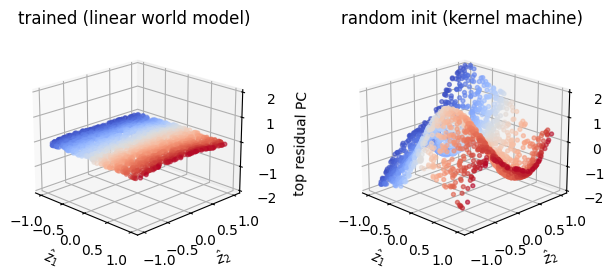

In [22]:
def fwd_plus_residual_axis(model, x_test, z_test_np):
    f_te = features(model, x_test)
    f_tr = features(model, x_train)
    mu = f_tr.mean(0, keepdims=True)
    fc_tr, fc_te = f_tr - mu, f_te - mu
    reg = Ridge(alpha=1e-3).fit(fc_tr, z_tr_np)
    z_hat_tr, z_hat_te = reg.predict(fc_tr), reg.predict(fc_te)
    W = reg.coef_
    _, _, Vt = np.linalg.svd(W, full_matrices=True)
    N = Vt[2:].T
    fc_null_tr = fc_tr @ N
    _, _, Vn = np.linalg.svd(fc_null_tr, full_matrices=False)
    top_null = N @ Vn[0]
    r_tr, r_te = fc_tr @ top_null, fc_te @ top_null
    # residualize r against ẑ to remove any linear-in-z component
    reg_r = Ridge(alpha=1e-3).fit(z_hat_tr, r_tr)
    r_te = r_te - reg_r.predict(z_hat_te)
    return z_hat_te[:, 0], z_hat_te[:, 1], r_te

zh1_t, zh2_t, r_t = fwd_plus_residual_axis(model_t, x_test, z_test.cpu().numpy())
zh1_r, zh2_r, r_r = fwd_plus_residual_axis(model_r, x_test, z_test.cpu().numpy())

plot_size = 0.7
fig = plt.figure(figsize=plot_size * np.array((10, 4)))
for i, (zh1, zh2, r, title) in enumerate([
    (zh1_t, zh2_t, r_t, 'trained (linear world model)'),
    (zh1_r, zh2_r, r_r, 'random init (kernel machine)'),
]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(zh1, zh2, r, c=z_test[:, 0].cpu(), s=8, cmap='coolwarm', alpha=0.6)
    ax.set_xlabel(r'$\hat z_1$'); ax.set_ylabel(r'$\hat z_2$')
    ax.set_zlabel('top residual PC')
    ax.set_title(title)
    ax.view_init(elev=20, azim=-45)

zmax = max(np.abs(np.r_[r_t, r_r]))
for ax in fig.axes:
    ax.set_zlim(-zmax, zmax)

plt.tight_layout()
plt.savefig('fig_simulation_3d.png', dpi=500)
plt.show()